In [3]:
!pip install opencv-python==4.10.0.84 numpy==1.26.4 matplotlib==3.8.0 sounddevice==0.5.1

In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import random

# ==========================================
# 1. SETUP AND CONFIGURATION
# ==========================================

DATA_PATH = '/kaggle/input/landmarks-dataset-v3/landmarks'
TARGET_COUNT = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


In [5]:
# ==========================================
# 2. DATA PREPROCESSING & LEAKAGE CONTROL
# ==========================================

def load_metadata(root_path):
    all_entries = []
    gestures = sorted([d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))])

    for ges in gestures:
        ges_folder = os.path.join(root_path, ges)
        files = [f for f in os.listdir(ges_folder) if f.endswith('.npy')]

        for f in files:
            # Filename pattern: gesture_group_person_repetition.npy
            # Example: abang_1_4_3.npy -> parts: ['abang', '1', '4', '3']
            parts = f.replace('.npy', '').split('_')
            
            # Extracting person_id based on your naming convention
            # parts[-3] is Group, parts[-2] is Person
            person_id = f"{parts[-3]}_{parts[-2]}" 
            
            # DATA LEAKAGE CONSTRAINT KEY:
            # Ensures all repetitions of the same person doing the same gesture 
            # stay together in the same fold (Train, Val, or Test).
            leakage_group_key = f"{ges}_{person_id}"
            
            all_entries.append({
                'path': os.path.join(ges_folder, f),
                'label': ges,
                'group': leakage_group_key
            })
            
    return all_entries, gestures

In [6]:
# ==========================================
# 3. CUSTOM DATASET
# ==========================================

class MSLDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.labels = labels
        self.augment = augment
        
        # Slicing for 3D landmarks (226 features)
        self.pose_x = slice(0, 100, 4)
        self.pose_y = slice(1, 100, 4)
        self.pose_z = slice(2, 100, 4)
        self.hand_x = slice(100, 226, 3)
        self.hand_y = slice(101, 226, 3)
        self.hand_z = slice(102, 226, 3)

        print(f"Pre-loading {len(paths)} samples into RAM...")
        self.data_cache = []
        for p in paths:
            raw_data = np.load(p)
            # Standardize everything to the center during load
            centered_data = self.center_normalization(raw_data)
            self.data_cache.append(centered_data)
        
        self.data_cache = np.array(self.data_cache) 

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        data = self.data_cache[idx].copy()
        
        if self.augment:
            # 1. Handedness Flip (0.5 prob)
            if np.random.random() > 0.5:
                data = self.horizontal_flip(data)

            # 2. Rotation (Keep it small)
            angle = np.random.uniform(-0.15, 0.15) 
            data = self.rotate_data(data, angle)

            # 3. Stable Scaling
            scale = np.random.uniform(0.9, 1.1)
            data = data * scale

            # 4. Reduced Jitter (Noise)
            # Only apply to X, Y, Z. Do not apply to visibility (the 4th value in Pose)
            # We create a mask to avoid shaking the visibility index
            noise = np.random.normal(0, 0.0015, data.shape) 
            
            # Zero out noise for visibility indices (3, 7, 11... up to 99)
            noise[:, 3:100:4] = 0 
            
            data = data + noise
        
        return torch.tensor(data, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)
        
    def center_normalization(self, data):
        """Unified normalization logic."""
        normalized = data.copy()
        for t in range(data.shape[0]):
            # Use Shoulders as the anchor point
            cx = (data[t, 44] + data[t, 48]) / 2
            cy = (data[t, 45] + data[t, 49]) / 2
            
            normalized[t, self.pose_x] -= cx
            normalized[t, self.pose_y] -= cy
            normalized[t, self.hand_x] -= cx
            normalized[t, self.hand_y] -= cy
        return normalized

    def horizontal_flip(self, data):
        """Creates a left-handed version of a right-handed sign."""
        flipped_data = data.copy()
        # 1. Negate X coordinates
        flipped_data[:, self.pose_x] = -flipped_data[:, self.pose_x]
        flipped_data[:, self.hand_x] = -flipped_data[:, self.hand_x]
        
        # 2. IMPORTANT: Swap LH (100:163) and RH (163:226) data segments
        # Because in a flip, the hand on the left of the screen is now the other hand
        left_hand_tmp = flipped_data[:, 100:163].copy()
        flipped_data[:, 100:163] = flipped_data[:, 163:226]
        flipped_data[:, 163:226] = left_hand_tmp
        return flipped_data

    def rotate_data(self, data, angle):
        """Rotates landmarks around the Z-axis (screen rotation)."""
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        # Apply 2D rotation matrix to X and Y coordinates
        for x_slice, y_slice in [(self.pose_x, self.pose_y), (self.hand_x, self.hand_y)]:
            x = data[:, x_slice]
            y = data[:, y_slice]
            data[:, x_slice] = x * cos_a - y * sin_a
            data[:, y_slice] = x * sin_a + y * cos_a
        return data
        
# 1. Load Metadata
metadata, gesture_list = load_metadata(DATA_PATH)
label_map = {name: i for i, name in enumerate(gesture_list)}

paths = np.array([m['path'] for m in metadata])
labels = np.array([label_map[m['label']] for m in metadata])
groups = np.array([m['group'] for m in metadata])

# 2. Step-by-Step Splitting (Respecting Groups)
sgkf_test = StratifiedGroupKFold(n_splits=7) 
train_val_idx, test_idx = next(sgkf_test.split(paths, labels, groups))

paths_tv, labels_tv, groups_tv = paths[train_val_idx], labels[train_val_idx], groups[train_val_idx]

sgkf_val = StratifiedGroupKFold(n_splits=6)
train_idx_raw, val_idx_raw = next(sgkf_val.split(paths_tv, labels_tv, groups_tv))

train_idx = train_val_idx[train_idx_raw]
val_idx = train_val_idx[val_idx_raw]

# 3. Distribution Report
train_counts = Counter(labels[train_idx])
print(f"\n--- DATASET DISTRIBUTION REPORT ---")
print(f"Total Unique Classes:   {len(gesture_list)}")
print(f"Training Samples (Raw): {len(train_idx)}")
print(f"Validation Samples:     {len(val_idx)}")
print(f"Test Samples:           {len(test_idx)}")


--- DATASET DISTRIBUTION REPORT ---
Total Unique Classes:   52
Training Samples (Raw): 3504
Validation Samples:     701
Test Samples:           700


In [7]:
# ==========================================
# 4. PATH-BASED BALANCING (UPSAMPLING)
# ==========================================

balanced_train_paths = []
balanced_train_labels = []

print(f"\nUpsampling Training Paths to {TARGET_COUNT} samples per class...")

for name, idx in label_map.items():
    # Get all training indices for this specific class
    class_indices = [i for i in train_idx if labels[i] == idx]
    if len(class_indices) == 0: continue

    upsampled_indices = np.random.choice(class_indices, TARGET_COUNT, replace=True)
    
    for i in upsampled_indices:
        balanced_train_paths.append(paths[i])
        balanced_train_labels.append(labels[i])

# Create Dataset Objects
# Note: Augment=True only for training
train_dataset = MSLDataset(balanced_train_paths, balanced_train_labels, augment=True)
val_dataset = MSLDataset(paths[val_idx], labels[val_idx], augment=False)
test_dataset = MSLDataset(paths[test_idx], labels[test_idx], augment=False)

# Create DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Balanced Train Samples: {len(train_dataset)}")


Upsampling Training Paths to 100 samples per class...
Pre-loading 5200 samples into RAM...
Pre-loading 701 samples into RAM...
Pre-loading 700 samples into RAM...
Balanced Train Samples: 5200


# Training Model

In [8]:
# ==========================================
# 5. TRANSFORMER MODEL ARCHITECTURE
# ==========================================

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=500):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class SignLanguageTransformer(nn.Module):
    def __init__(self, input_size, num_classes, d_model=128, nhead=4, num_layers=3, dim_feedforward=256, dropout=0.1):
        super(SignLanguageTransformer, self).__init__()
        self.input_projection = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                   dim_feedforward=dim_feedforward, 
                                                   dropout=dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, num_classes)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x.mean(dim=1) # Global Average Pooling
        x = self.fc_out(x)
        return x

num_classes = len(gesture_list)

# Initialize
sample_x, _ = train_dataset[0]
input_size = sample_x.shape[1]

model = SignLanguageTransformer(input_size, num_classes).to(DEVICE)
print(f"Model Initialized with input size of {input_size} for {num_classes} classes.")

Model Initialized with input size of 226 for 52 classes.


In [9]:
# ==========================================
# 6. TRAINING LOOP
# ==========================================

criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)
lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=7)

num_epochs = 200
best_val_loss = float('inf')
es_patience = 20
epochs_no_improve = 0
best_model_path = 'transformer_model.pth'

train_losses, val_losses, train_accs, val_accs = [], [], [], []

print("Starting Training...")

for epoch in range(num_epochs):
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_train += y_batch.size(0)
        correct_train += (predicted == y_batch).sum().item()
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct_train / total_train
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
    
    # Validation
    model.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
        
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            running_val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_val += y_batch.size(0)
            correct_val += (predicted == y_batch).sum().item()
            
    val_loss = running_val_loss / len(val_loader)
    val_acc = correct_val / total_val
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    lr_scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= es_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Load Best Model
model.load_state_dict(torch.load(best_model_path))
print("Best model loaded.")

Starting Training...
Epoch [10/200] | Train Loss: 2.1048 Acc: 0.4208 | Val Loss: 2.0579 Acc: 0.4351
Epoch [20/200] | Train Loss: 1.2727 Acc: 0.6540 | Val Loss: 1.3953 Acc: 0.6291
Epoch [30/200] | Train Loss: 0.7107 Acc: 0.8150 | Val Loss: 0.9818 Acc: 0.7147
Epoch [40/200] | Train Loss: 0.4169 Acc: 0.8948 | Val Loss: 0.7937 Acc: 0.7718
Epoch [50/200] | Train Loss: 0.2679 Acc: 0.9335 | Val Loss: 0.6558 Acc: 0.8217
Epoch [60/200] | Train Loss: 0.1710 Acc: 0.9610 | Val Loss: 0.6454 Acc: 0.8160
Epoch [70/200] | Train Loss: 0.1154 Acc: 0.9756 | Val Loss: 0.6376 Acc: 0.8488
Epoch [80/200] | Train Loss: 0.0755 Acc: 0.9860 | Val Loss: 0.6645 Acc: 0.8388
Epoch [90/200] | Train Loss: 0.0547 Acc: 0.9927 | Val Loss: 0.6010 Acc: 0.8516
Early stopping at epoch 93
Best model loaded.


In [10]:
# ==========================================
# 7. EXPORT TO ONNX
# ==========================================

import torch.onnx

model.eval()
dummy_input = torch.randn(1, 30, 226).to(DEVICE)

onnx_model_path = "transformer_model.onnx"

print(f"Exporting model to {onnx_model_path}...")

torch.onnx.export(
    model,                      # The trained model
    dummy_input,                # Dummy input to trace the graph
    onnx_model_path,            # Output filename
    export_params=True,         # Store the trained parameter weights inside the model file
    opset_version=14,           # The ONNX version to use
    do_constant_folding=True,   # Whether to execute constant folding for optimization
    input_names=['input'],      # The model's input name
    output_names=['output'],    # The model's output name
    # Dynamic axes allow the model to handle different batch sizes during inference
    dynamic_axes={
        'input': {0: 'batch_size'}, 
        'output': {0: 'batch_size'}
    }
)

print("ONNX export complete!")

Exporting model to transformer_model.onnx...


/tmp/ipykernel_113/2901424295.py:14: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


ONNX export complete!


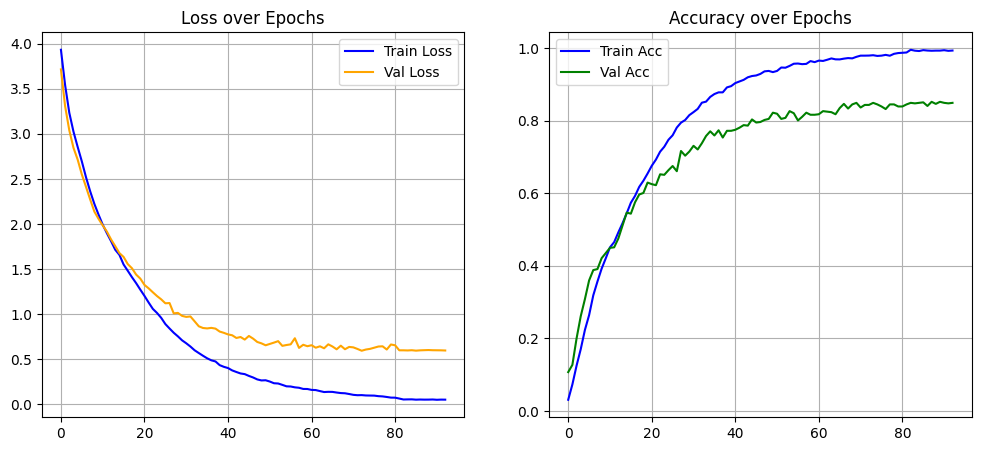

In [11]:
# ==========================================
# 8. EVALUATION & VISUALIZATION
# ==========================================

# Training History Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss', color='blue')
plt.plot(val_losses, label='Val Loss', color='orange')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc', color='blue')
plt.plot(val_accs, label='Val Acc', color='green')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
print("\nEvaluating on Test Set...")
model.eval()

y_true = []
y_pred = []

# Iterate through the test loader to collect all predictions
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        # Move batch to device
        X_batch = X_batch.to(DEVICE)
        
        # Get predictions
        outputs = model(X_batch)
        _, predicted = torch.max(outputs, 1)
        
        # Store results (move back to CPU for numpy compatibility)
        y_true.extend(y_batch.numpy())
        y_pred.extend(predicted.cpu().numpy())

# Convert lists to numpy arrays for reporting
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Print Accuracy
accuracy = np.mean(y_pred == y_true)
print(f"Test Accuracy: {accuracy:.4f}")


Evaluating on Test Set...
Test Accuracy: 0.8586


In [13]:
# 2. Classification Report
print("\nClassification Report:")
all_labels = list(range(num_classes)) 

print(classification_report(
    y_true, 
    y_pred, 
    labels=all_labels,       
    target_names=gesture_list,   
    zero_division=0          # Return 0 instead of crashing/warning for missing classes
))


Classification Report:
                 precision    recall  f1-score   support

          abang       0.75      1.00      0.86         9
    anak_lelaki       0.69      0.75      0.72        12
 anak_perempuan       0.86      0.80      0.83        15
            apa       1.00      0.78      0.88         9
     apa_khabar       0.67      0.93      0.78        15
assalamualaikum       0.60      0.50      0.55        12
           ayah       1.00      1.00      1.00        12
      bagaimana       1.00      0.92      0.96        12
 bahasa_isyarat       0.38      1.00      0.55         6
           baik       0.76      0.79      0.78        24
   bapa_saudara       1.00      1.00      1.00        12
           beli       1.00      0.93      0.97        15
         beli_2       0.92      0.80      0.86        15
         berapa       1.00      0.78      0.88         9
           bila       0.92      1.00      0.96        12
          bomba       0.79      0.92      0.85        12
      

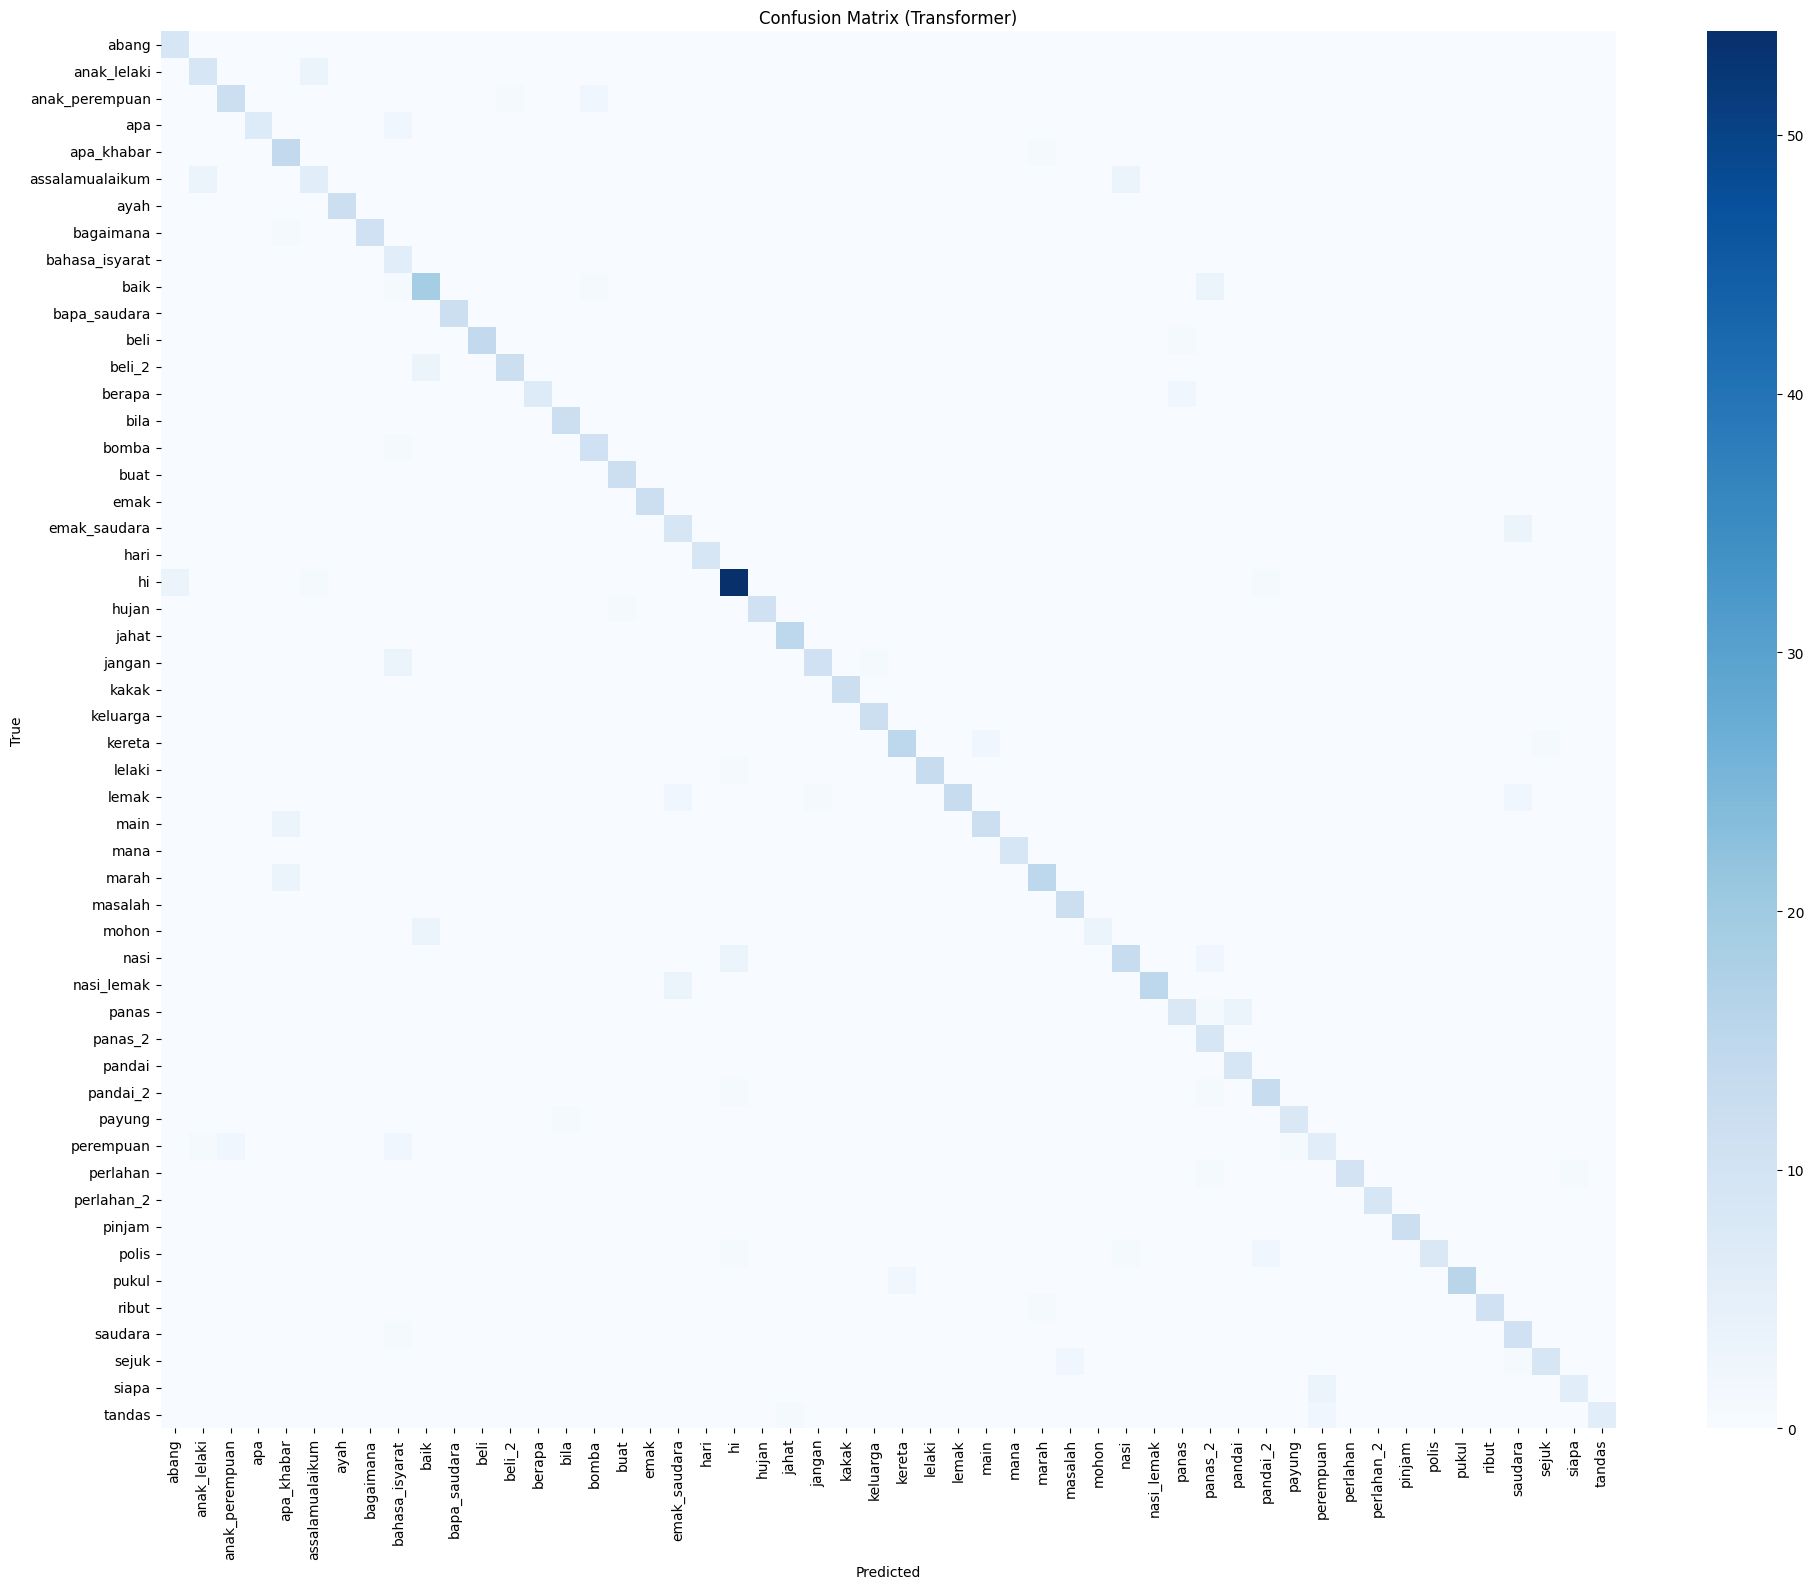

In [14]:
# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=all_labels)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=gesture_list, yticklabels=gesture_list)
plt.title("Confusion Matrix (Transformer)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()